# CPT for PINN papers on Gemma 3 4B

`google/gemma-3-4b-pt` is a 4B base model and is suitable for custom post-training. We implement CPT on the `pymlex/pinn-arxiv` dataset that contains metadata-only articles on Physics Informed Neural Networks (PINNs) to let the model answer more precisely on the topics from this domain.

## Installation

In [ ]:
!pip install -U transformers accelerate peft trl huggingface-hub datasets pandas requests plotly seaborn scipy

## Imports and configuration

In [4]:
import os
import json
import subprocess

import pandas as pd
import requests
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainerCallback
from peft import LoraConfig, PeftModel
from trl import SFTTrainer, SFTConfig
from huggingface_hub import hf_hub_download, login

hf_dataset_id = "pymlex/pinn-arxiv"
base_model_id = "google/gemma-3-4b-pt"
hub_model_id = "pymlex/gemma3-4b-pinn-expert"

output_dir = "./gemma3_4b_pinn_cpt"
seed = 3407

torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

bf16 = torch.cuda.is_bf16_supported()
fp16 = not bf16

device_name = torch.cuda.get_device_name(0)
device_props = torch.cuda.get_device_properties(0)
vram_gb = device_props.total_memory / (1024 ** 3)

print(f"GPU: {device_name}")
print(f"VRAM: {vram_gb:.2f} GB")

GPU: NVIDIA GeForce RTX 5090
VRAM: 31.32 GB


## Dataset download and cleanup

`matched_queries` and `comment` are removed after loading. The dataset is split into `train/validation/test` with a `90/5/5` ratio.

In [5]:
repo_id = "pymlex/pinn-arxiv"
filename = "pinn_arxiv_metadata.jsonl"

local_path = hf_hub_download(
    repo_id=repo_id,
    repo_type="dataset",
    filename=filename
)

rows = []

with open(local_path, "r", encoding="utf-8") as f:
    for line in f:
        row = json.loads(line)

        title = row.get("title", "")
        authors = row.get("authors", [])
        published = row.get("published", "")
        updated = row.get("updated", "")
        summary = row.get("summary", "")
        categories = row.get("categories", [])
        primary_category = row.get("primary_category", "")

        text = (
            f"Title: {title}\n"
            f"Authors: {', '.join(authors)}\n"
            f"Published: {published}\n"
            f"Updated: {updated}\n"
            f"Summary: {summary}\n"
            f"Categories: {', '.join(categories)}\n"
            f"Primary category: {primary_category}"
        )

        rows.append({
            "text": text
        })

df = pd.DataFrame(rows)
df["text_len"] = df["text"].str.len()

print(df.shape)
df.head()

(2598, 2)


,text,text_len
0,Title: Physics Informed Deep Learning (Part I)...,1322
1,Title: Physics Informed Deep Learning (Part II...,1105
2,Title: Physically-informed artificial neural n...,1703
3,Title: Quantifying total uncertainty in physic...,2246
4,Title: Adversarial Uncertainty Quantification ...,1490


We want to enhance Gemma's ability to understand PINNs, so we use CPT as a key solution for plain language modeling. We formatted the source records as compact, flattened text blocks with basic information, e. g. dates and authors. All another metadata is removed. Final texts are shorter than $2250 / 4 \approx 560$ tokens.

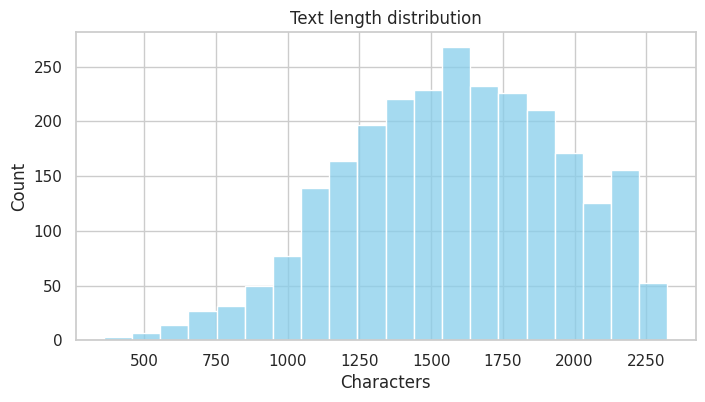

In [6]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 4))

sns.histplot(df, x="text_len", bins=20, color="skyblue")

plt.title("Text length distribution")
plt.xlabel("Characters")
plt.ylabel("Count")
plt.show()

In [16]:
max_seq_length = 1024

In [7]:
dataset = Dataset.from_pandas(df[["text"]], preserve_index=False)
split_1 = dataset.train_test_split(test_size=0.1, seed=seed)
split_2 = split_1["test"].train_test_split(test_size=0.5, seed=seed)

train_base = split_1["train"]
val_base = split_2["train"]
test_base = split_2["test"]

train_base, val_base, test_base

(Dataset({
     features: ['text'],
     num_rows: 2338
 }),
 Dataset({
     features: ['text'],
     num_rows: 130
 }),
 Dataset({
     features: ['text'],
     num_rows: 130
 }))

## Base model and LoRA

The model is loaded in bf16 without quantization. Make sure to accept Google's terms of use [here](https://huggingface.co/google/gemma-3-4b-pt).

In [8]:
tokenizer = AutoTokenizer.from_pretrained(base_model_id)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    device_map="auto",
    torch_dtype=torch.bfloat16 if bf16 else torch.float16,
)

model.config.use_cache = False

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
)

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

## Datasets and Dataloader

In [35]:
def format_example(example):
    text = example["text"] + tokenizer.eos_token
    n_tokens = len(tokenizer(text, add_special_tokens=False)["input_ids"])
    return {"text": text, "n_tokens": n_tokens}


train_ds = train_base.map(format_example, remove_columns=train_base.column_names)
val_ds = val_base.map(format_example, remove_columns=val_base.column_names)
test_ds = test_base.map(format_example, remove_columns=test_base.column_names)


train_ds = train_ds.filter(lambda x: x["n_tokens"] <= max_seq_length)
val_ds = val_ds.filter(lambda x: x["n_tokens"] <= max_seq_length)
test_ds = test_ds.filter(lambda x: x["n_tokens"] <= max_seq_length)


train_ds = train_ds.remove_columns(["n_tokens"])
val_ds = val_ds.remove_columns(["n_tokens"])
test_ds = test_ds.remove_columns(["n_tokens"])

Map:   0%|          | 0/2338 [00:00<?, ? examples/s]

Map:   0%|          | 0/130 [00:00<?, ? examples/s]

Map:   0%|          | 0/130 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2338 [00:00<?, ? examples/s]

Filter:   0%|          | 0/130 [00:00<?, ? examples/s]

Filter:   0%|          | 0/130 [00:00<?, ? examples/s]

## Training setup

We use evaluation each 10 epochs, save the model each 15 and always log the loss and GPU usage.

In [7]:
class TrainStatusCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs:
            return

        if not torch.cuda.is_available():
            return

        device_id = torch.cuda.current_device()
        raw = subprocess.check_output([
            "nvidia-smi",
            "--query-gpu=utilization.gpu,memory.used,memory.total",
            "--format=csv,noheader,nounits",
        ]).decode("utf-8").strip().splitlines()[device_id]

        gpu_util, mem_used, mem_total = [x.strip() for x in raw.split(",")]

        loss = logs.get("loss", None)
        eval_loss = logs.get("eval_loss", None)

        msg = f"[STEP {state.global_step}] "

        if loss is not None:
            msg += f"loss={loss:.4f} | "

        if eval_loss is not None:
            msg += f"eval_loss={eval_loss:.4f} | "

        msg += f"GPU={gpu_util}% | VRAM={mem_used}/{mem_total} MB"
        print(msg)


training_args = SFTConfig(
    output_dir=output_dir,
    per_device_train_batch_size=6,
    gradient_accumulation_steps=4,
    num_train_epochs=2,
    learning_rate=1e-4,
    warmup_steps=50,
    lr_scheduler_type="cosine",
    optim="adamw_torch",

    logging_strategy="steps",
    logging_steps=1,

    eval_strategy="steps",
    eval_steps=10,
    eval_on_start=True,

    save_strategy="steps",
    save_steps=50,

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    bf16=bf16,
    fp16=fp16,
    report_to="none",
    seed=seed,
    packing=False,
    dataset_text_field="text",
    max_length=max_seq_length,
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    peft_config=lora_config,
)

trainer.add_callback(TrainStatusCallback())

Adding EOS to train dataset:   0%|          | 0/2338 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/2338 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/130 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/130 [00:00<?, ? examples/s]

## Training and saving

In [8]:
train_result = trainer.train()
train_result

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1, 'bos_token_id': 2, 'pad_token_id': 0}.


Step,Training Loss,Validation Loss
0,No log,2.213270
10,2.168619,2.180262
20,1.895543,2.034952
30,1.970295,1.989547
40,1.903698,1.962301
50,1.946181,1.937548
60,1.955869,1.931450
70,1.980987,1.926741
80,1.792468,1.920950
90,1.872491,1.917926


[STEP 0] eval_loss=2.2133 | GPU=95% | VRAM=27718/32607 MB
[STEP 1] loss=2.2215 | GPU=3% | VRAM=28126/32607 MB
[STEP 2] loss=2.2008 | GPU=83% | VRAM=28126/32607 MB
[STEP 3] loss=2.1925 | GPU=63% | VRAM=28126/32607 MB
[STEP 4] loss=2.2129 | GPU=98% | VRAM=28126/32607 MB
[STEP 5] loss=2.2537 | GPU=97% | VRAM=28126/32607 MB
[STEP 6] loss=2.2053 | GPU=75% | VRAM=28126/32607 MB
[STEP 7] loss=2.2279 | GPU=98% | VRAM=28126/32607 MB
[STEP 8] loss=2.1075 | GPU=97% | VRAM=28126/32607 MB
[STEP 9] loss=2.1846 | GPU=97% | VRAM=28126/32607 MB
[STEP 10] loss=2.1686 | GPU=98% | VRAM=28126/32607 MB
[STEP 10] eval_loss=2.1803 | GPU=72% | VRAM=28126/32607 MB
[STEP 11] loss=2.1832 | GPU=84% | VRAM=28126/32607 MB
[STEP 12] loss=2.2030 | GPU=97% | VRAM=28126/32607 MB
[STEP 13] loss=2.1911 | GPU=98% | VRAM=28126/32607 MB
[STEP 14] loss=2.1108 | GPU=97% | VRAM=28126/32607 MB
[STEP 15] loss=2.1536 | GPU=97% | VRAM=28126/32607 MB
[STEP 16] loss=2.1451 | GPU=97% | VRAM=28126/32607 MB
[STEP 17] loss=2.0369 | GPU=9

TrainOutput(global_step=196, training_loss=1.9095789954370381, metrics={'train_runtime': 582.007, 'train_samples_per_second': 8.034, 'train_steps_per_second': 0.337, 'total_flos': 4.369029276341184e+16, 'train_loss': 1.9095789954370381})

Loss converges with visible oscillations but the general trend is decrease.

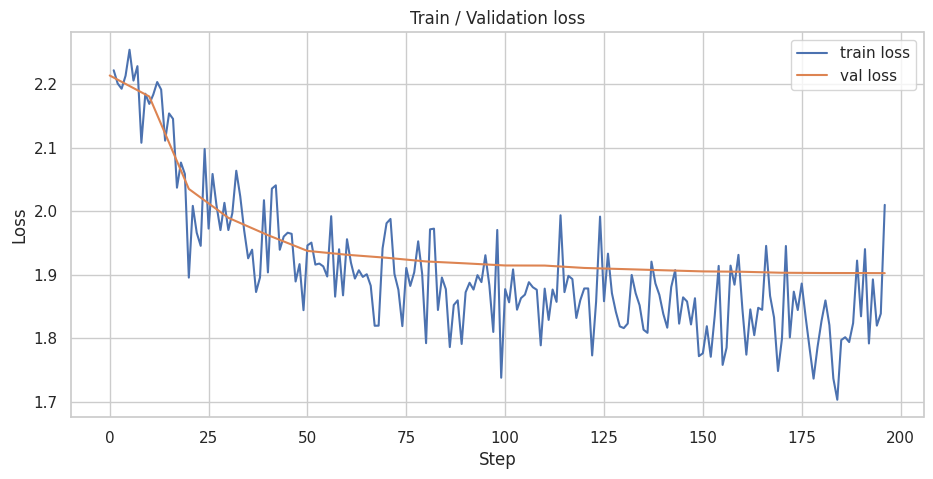

In [9]:
logs = pd.DataFrame(trainer.state.log_history)

train_logs = logs[["step", "loss"]].dropna()
eval_logs = logs[["step", "eval_loss"]].dropna()

plt.figure(figsize=(11, 5))

plt.plot(train_logs["step"], train_logs["loss"], label="train loss")
plt.plot(eval_logs["step"], eval_logs["eval_loss"], label="val loss")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Train / Validation loss")
plt.legend()
plt.grid(True)
plt.show()

We load the best checkpoint (step 150) and push it to HF.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(base_model_id)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    device_map="auto",
    torch_dtype=torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16,
)

checkpoint_path = f"{output_dir}/checkpoint-150"
model = PeftModel.from_pretrained(base_model, checkpoint_path)
model.eval()

In [13]:
model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

login(token="YOUR_TOKEN")

model.push_to_hub(hub_model_id)
tokenizer.push_to_hub(hub_model_id)

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/pymlex/gemma3-4b-pinn-expert/commit/a777bf2846dcc5c7eb147e68ee7c0479511deb4d', commit_message='Upload tokenizer', commit_description='', oid='a777bf2846dcc5c7eb147e68ee7c0479511deb4d', pr_url=None, repo_url=RepoUrl('https://huggingface.co/pymlex/gemma3-4b-pinn-expert', endpoint='https://huggingface.co', repo_type='model', repo_id='pymlex/gemma3-4b-pinn-expert'), pr_revision=None, pr_num=None)

## Inference

These are the daily use cells.

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

base_model_id = "google/gemma-3-4b-pt"
adapter_id = "pymlex/gemma3-4b-pinn-expert"

tokenizer = AutoTokenizer.from_pretrained(base_model_id)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    device_map="auto",
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16,
)

model = PeftModel.from_pretrained(base_model, adapter_id)
model.eval()

In [14]:
def build_prompt(record):
    return (
        f"Title: {record.get('Title', '')}\n"
        f"Authors: {record.get('Authors', '')}\n"
        f"Published: {record.get('Published', '')}\n"
        f"Updated: {record.get('Updated', '')}\n"
        f"Summary: "
    )


def generate_continuation(model, tokenizer, prompt, max_new_tokens=220):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            num_beams=1,
            repetition_penalty=1.1,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
        )

    prompt_len = inputs["input_ids"].shape[1]
    continuation_ids = outputs[0, prompt_len:]

    continuation = tokenizer.decode(continuation_ids, skip_special_tokens=True)
    return continuation


sample_record = {
    "Title": "fPINNs: Fractional Physics-Informed Neural Networks",
    "Authors": "Guofei Pang, Lu Lu, George Em Karniadakis",
    "Published": "2018-11-20T02:48:36Z",
    "Updated": "2018-11-20T02:48:36Z",
}

prompt = build_prompt(sample_record)
output = generate_continuation(model, tokenizer, prompt, max_new_tokens=400)
print("Prompt:")
print(prompt)
print("\nGenerated continuation:")
print(output)

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

adapter_config.json: 0.00B [00:00, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/131M [00:00<?, ?B/s]

[transformers] The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Prompt:
Title: fPINNs: Fractional Physics-Informed Neural Networks
Authors: Guofei Pang, Lu Lu, George Em Karniadakis
Published: 2018-11-20T02:48:36Z
Updated: 2018-11-20T02:48:36Z
Summary: 

Generated continuation:
1. We propose a novel framework for solving fractional partial differential equations (PDEs) using physics-informed neural networks (PINNs). The proposed method is called fractional PINN (fPINN), which can be used to solve both linear and nonlinear fractional PDEs with Caputo derivatives of arbitrary order. 2. In the proposed approach, we use a deep neural network to approximate the solution of the fractional PDE. The loss function is constructed by combining the residual term of the fractional PDE with the data points in the training set. 3. To demonstrate the effectiveness of our method, we apply it to several benchmark problems including the Burgers equation, Allen-Cahn equation, and Fisher's equation. Numerical results show that the proposed method achieves high accuracy

## Perplexity evaluation on test

In [28]:
import numpy as np
import torch
import pandas as pd
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

def compute_perplexity(model, tokenizer, dataset, max_length=1024):
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    with torch.inference_mode():
        for example in tqdm(dataset):
            text = example["text"] + tokenizer.eos_token
            encodings = tokenizer(text, truncation=True, max_length=max_length, return_tensors="pt").to(model.device)
            outputs = model(**encodings, labels=encodings["input_ids"])
            loss = outputs.loss
            n_tokens = encodings["input_ids"].numel()
            total_loss += loss.item() * n_tokens
            total_tokens += n_tokens
    avg_loss = total_loss / total_tokens
    perplexity = np.exp(avg_loss)
    return perplexity, avg_loss

base_model_id = "google/gemma-3-4b-pt"
tokenizer = AutoTokenizer.from_pretrained(base_model_id)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    device_map="auto",
    torch_dtype=torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16,
)

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

We use the whole test set.

The tuned model shows a significant performance leap. It is less surprised by new tokens, even on the test set. The improvement in perplexity is 28%.

In [29]:
ppl_base, loss_base = compute_perplexity(base_model, tokenizer, test_ds)
print(f"Base model: Perplexity = {ppl_base:.3f}, Loss = {loss_base:.4f}")

adapter_id = "pymlex/gemma3-4b-pinn-expert"
model = PeftModel.from_pretrained(base_model, adapter_id)
ppl_tuned, loss_tuned = compute_perplexity(model, tokenizer, test_ds)
print(f"Tuned model: Perplexity = {ppl_tuned:.3f}, Loss = {loss_tuned:.4f}")

pd.DataFrame([
    {"model": "base", "perplexity": ppl_base, "loss": loss_base},
    {"model": "tuned", "perplexity": ppl_tuned, "loss": loss_tuned},
])

  0%|          | 0/130 [00:00<?, ?it/s]

Base model: Perplexity = 9.200, Loss = 2.2192


  0%|          | 0/130 [00:00<?, ?it/s]

Tuned model: Perplexity = 6.646, Loss = 1.8941


,model,perplexity,loss
0,base,9.199807,2.219183
1,tuned,6.646412,1.894077
